In [ ]:
from pathlib import Path
import json
import pandas as pd

folder = Path(".").resolve().parent.parent / "experiments" / "cifar10" / "hyper"
names = {"SimpleNN", "LongLiquid", "BlockLiquid", "LongMoe", "BlockMoe"}

def get_mean_auc(folder: Path, name: str):
    n_lines = 0
    agg = 0

    if not (folder / f"{name}_accuracy.txt").is_file():
        return float("nan")

    with open(folder / f"{name}_accuracy.txt", "r") as f:
        for line in f:
            n_lines += 1
            agg += float(line)

    return agg / n_lines


def get_test_metrics(folder: Path, name: str) -> dict:


    with open(folder / f"{name}_test_metrics.txt", "r") as f:
        metrics = {}

        for line in f:
            key, value = line.split("=")
            metrics[key] = float(value)

    return metrics


def get_n_experts(folder: Path, name: str) -> int:

    if name == "SimpleNN":
        return 1

    with open(folder / "params.json", "r") as f:
        params = json.load(f)

    return params[name]["architecture"]["n_citizens"]

experiments = []

for ent in folder.iterdir():

    if not ent.is_dir():
        continue

    found = None
    for name in names:

        if not (ent / f"{name}.pt").is_file():
            continue

        assert found is None
        found = name

    assert found is not None

    try:
        metrics = get_test_metrics(ent, found)
        auc = get_mean_auc(ent, found)
        metrics["acc_auc"] = auc
        metrics["n_experts"] = get_n_experts(ent, found)

        experiments.append({
            "best_accuracy": metrics["best_accuracy"],
            "acc_auc": metrics["acc_auc"],
            "n_experts": metrics["n_experts"],
            "n_params": metrics["n_params"],
            "p_active": metrics["p_active_q_0.50"],
            "architecture": found
        })
    except FileNotFoundError as e:
        print(e)
        continue



df = pd.DataFrame(experiments)
df["active_n_params"] = df["n_params"] * df["p_active"]

# TODO filter block (moe and le) 15 experts before 2025-09-08 7:000

[Errno 2] No such file or directory: 'C:\\Users\\Viktor\\Documents\\liquid\\experiments\\cifar10\\hyper\\20250908_060448_first_BlockMoe_15_DRFuajkO\\BlockMoe_test_metrics.txt'
[Errno 2] No such file or directory: 'C:\\Users\\Viktor\\Documents\\liquid\\experiments\\cifar10\\hyper\\20250908_065238_first_BlockLiquid_15_vBALLRMx\\BlockLiquid_test_metrics.txt'


In [4]:
df.groupby(["n_experts", "architecture"]).size()

n_experts  architecture
1          SimpleNN        48
5          BlockLiquid     48
           BlockMoe        48
           LongLiquid      48
           LongMoe         48
10         BlockLiquid     48
           BlockMoe        48
           LongLiquid      48
           LongMoe         48
15         BlockLiquid     13
           BlockMoe        42
           LongLiquid      48
           LongMoe         48
dtype: int64

<Axes: ylabel='Frequency'>

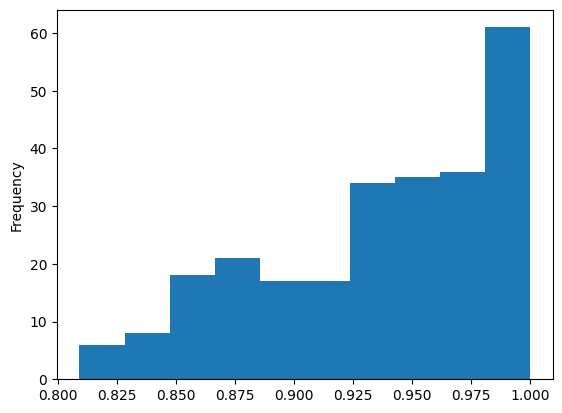

In [5]:
df[df["architecture"].str.contains("Liquid")]["p_active"].plot.hist()

<Axes: ylabel='Frequency'>

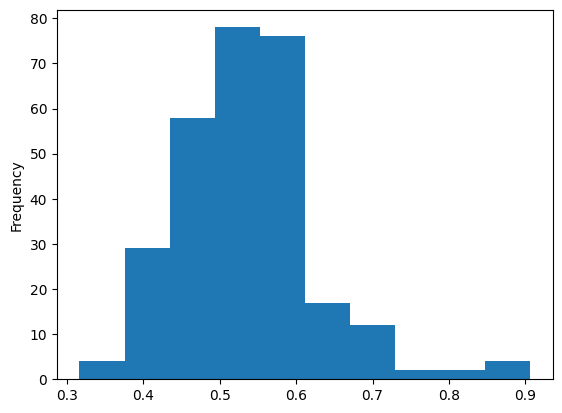

In [6]:
df[df["architecture"].str.contains("Moe")]["p_active"].plot.hist()

In [7]:
df = df[df["acc_auc"].notnull()]

<Axes: ylabel='Frequency'>

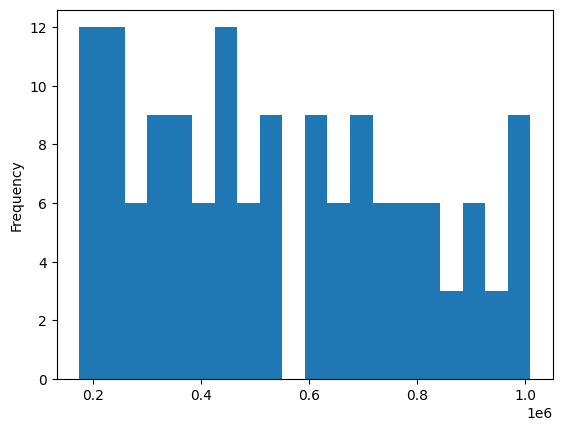

In [10]:
df[df["architecture"].str.contains("LongLiquid")]["n_params"].plot.hist(bins=20)

In [14]:
df

,best_accuracy,acc_auc,n_experts,n_params,p_active,architecture,active_n_params
0,0.735682,0.655846,5,203064.0,0.527941,LongMoe,107205.845208
1,0.758292,0.631388,1,180151.0,1.000000,SimpleNN,180151.000000
2,0.774837,0.655238,1,180151.0,1.000000,SimpleNN,180151.000000
3,0.760049,0.640622,1,180151.0,1.000000,SimpleNN,180151.000000
4,0.772038,0.649412,1,213694.0,1.000000,SimpleNN,213694.000000
...,...,...,...,...,...,...,...
578,0.767055,0.634122,15,803537.0,0.506852,BlockMoe,407274.192605
579,0.679126,0.465452,15,309225.0,0.883004,BlockLiquid,273046.859613
580,0.772631,0.667420,15,803537.0,0.543734,BlockMoe,436910.099094
581,0.639032,0.461836,15,309225.0,0.933371,BlockLiquid,288621.797226


In [19]:
df.groupby(["n_experts", "architecture", "n_params"]).size()

n_experts  architecture  n_params
1          SimpleNN      180151.0    3
                         213694.0    3
                         252084.0    3
                         292393.0    3
                         335185.0    3
                                    ..
15         LongMoe       701837.0    3
                         764346.0    3
                         829684.0    3
                         897521.0    3
                         967080.0    3
Length: 195, dtype: int64

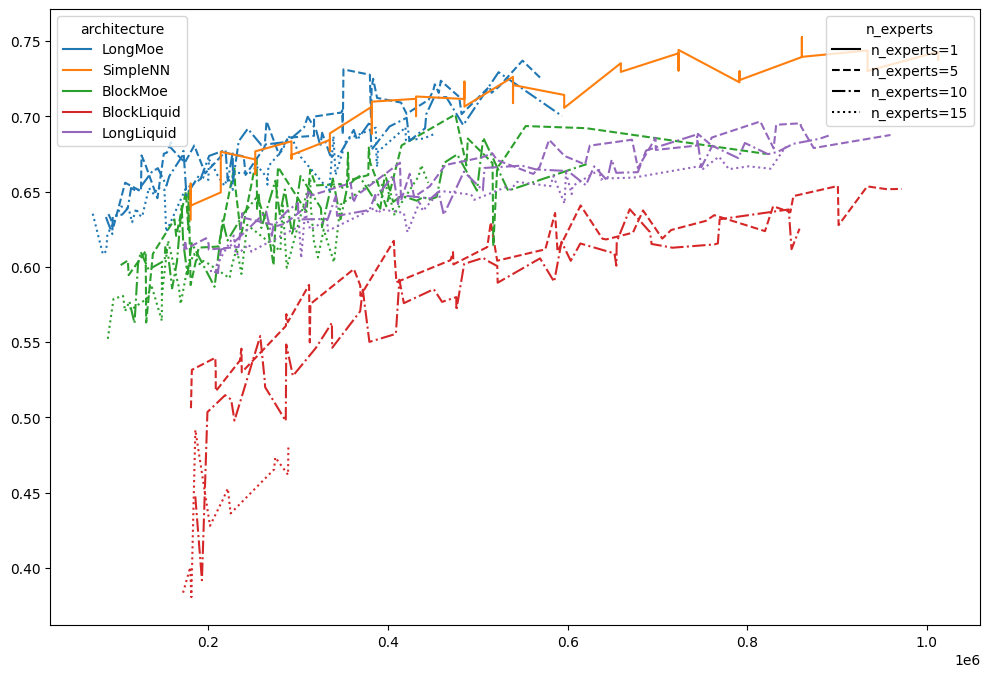

In [16]:
# params over top and AUC

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def plot_by_category(df, x_col, y_col):
    fig, ax = plt.subplots(figsize=(12, 8))

    architectures = df['architecture'].unique()
    n_experts_set = df['n_experts'].unique()

    colors = {arch: c for arch, c in zip(architectures, plt.cm.tab10.colors)}
    linestyles = {n: s for n, s in zip(sorted(n_experts_set), ['-', '--', '-.', ':'])}

    for (arch, n_exp), group in df.groupby(['architecture', 'n_experts']):
        group = group.sort_values(x_col)
        ax.plot(group[x_col], group[y_col], color=colors[arch], linestyle=linestyles[n_exp])

    color_lines = [mlines.Line2D([], [], color=colors[arch], linestyle='-', label=arch) for arch in architectures]
    style_lines = [mlines.Line2D([], [], color='black', linestyle=linestyles[n], label=f'n_experts={n}') for n in sorted(n_experts_set)]

    legend1 = ax.legend(handles=color_lines, title="architecture", loc='upper left')
    legend2 = ax.legend(handles=style_lines, title="n_experts", loc='upper right')
    ax.add_artist(legend1)

    plt.show()


plot_by_category(df, "active_n_params", "acc_auc")

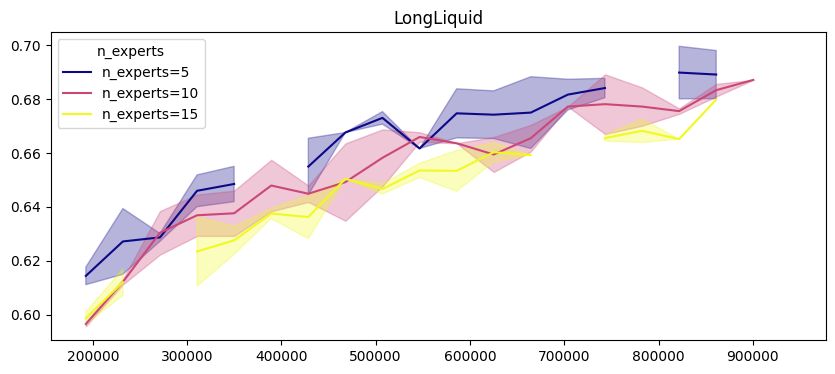

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_architecture(df, architecture, x_col, y_col, bins=None, ax=None):
    df_arch = df[df['architecture'] == architecture]
    n_experts_sorted = sorted(df_arch['n_experts'].unique())
    colors = plt.cm.plasma(np.linspace(0, 1, len(n_experts_sorted)))
    color_map = dict(zip(n_experts_sorted, colors))


    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    x_min, x_max = df_arch[x_col].min(), df_arch[x_col].max()
    bin_edges = np.linspace(x_min, x_max, bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    for n_exp in n_experts_sorted:
        sub = df_arch[df_arch['n_experts'] == n_exp].copy()
        sub['bin'] = pd.cut(sub[x_col], bins=bin_edges, include_lowest=True)
        grouped = sub.groupby('bin',  observed=False)[y_col]
        means = grouped.mean().values
        stds = grouped.std().fillna(0).values

        c = color_map[n_exp]
        ax.plot(bin_centers, means, color=c, label=f'n_experts={n_exp}')
        ax.fill_between(bin_centers, means - stds, means + stds, color=c, alpha=0.3)

    ax.set_title(architecture)
    ax.legend(title="n_experts")


plot_architecture(df, "LongLiquid", "active_n_params", "acc_auc")


KeyError: 'Column not found: auc_acc'

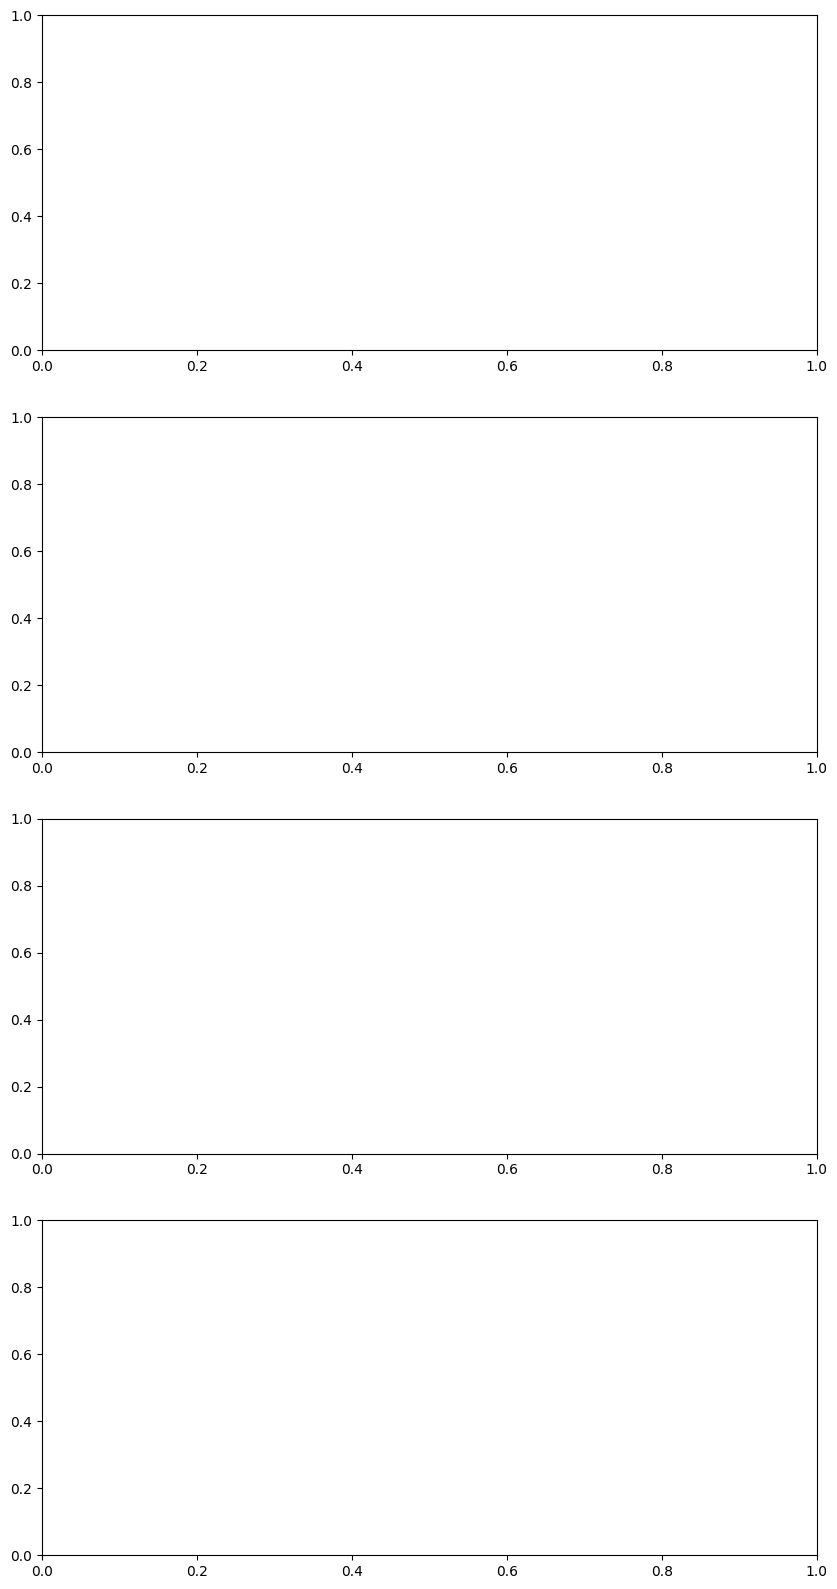

In [ ]:

fig, axs = plt.subplots(df["architecture"].unique().size, 1, figsize=(10, 20))

for ax, (arch, group) in zip(axs, df.groupby('architecture'), strict=True):

    plot_architecture(group, arch, "n_params", "auc_acc", ax=ax)

    ax.set_ylim([0, 1])

plt.show()